# 14 TreeCluster Threshold Sensitivity

**Methods mapping:** branch assignment threshold sensitivity.

This notebook summarizes how TreeCluster distance thresholds affect branch resolution, dominant cross-branch counts, and the permutation-based null expectation used for Supplementary Fig. S6.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image as IPyImage

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'config' / 'analysis_config.yaml').exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / 'notebooks'))
import analysis_utils as au
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
rel = lambda path: Path(path).relative_to(ROOT).as_posix()
ROOT


PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes')

In [2]:
DATA_DIR, FIG_DIR = au.step_dirs('14_treecluster_threshold_sensitivity', ROOT)
INPUTS = {
    'threshold_counts': DATA_DIR / 'treecluster_threshold_counts_and_enrichment.csv',
}
OUTPUTS = {
    'figure_png': FIG_DIR / 'Supplementary_Figure_S6_TreeCluster_threshold_sensitivity.png',
    'figure_pdf': FIG_DIR / 'Supplementary_Figure_S6_TreeCluster_threshold_sensitivity.pdf',
    'figure_svg': FIG_DIR / 'Supplementary_Figure_S6_TreeCluster_threshold_sensitivity.svg',
}
display(pd.DataFrame({'input': INPUTS.keys(), 'path': [rel(p) for p in INPUTS.values()]}))
display(pd.DataFrame({'output': OUTPUTS.keys(), 'path': [rel(p) for p in OUTPUTS.values()]}))


,input,path
0,threshold_counts,data/processed_data/14_treecluster_threshold_s...


,output,path
0,figure_png,results/figures/14_treecluster_threshold_sensi...
1,figure_pdf,results/figures/14_treecluster_threshold_sensi...
2,figure_svg,results/figures/14_treecluster_threshold_sensi...


## Read Threshold Table

The table contains observed dominant cross-branch counts, null means and 95% intervals, and branch-resolution summaries for each threshold.


In [3]:
thresholds = pd.read_csv(INPUTS['threshold_counts'])

display(thresholds.head())
display(thresholds[thresholds['is_main_threshold']][['project_label', 'TreeCluster_threshold', 'dominant_combo', 'dominant_combo_samples', 'permuted_mean', 'permuted_q025', 'permuted_q975']])


,project,project_label,TreeCluster_threshold,is_main_threshold,analysis_status,n_samples,n_haplotypes,n_treecluster_branches,n_unclustered_haplotypes,unclustered_haplotype_fraction,n_multi_haplotype_samples,n_cross_branch_samples,n_distinct_cross_branch_combos,dominant_combo,dominant_combo_samples,dominant_count_over_cross_branch,dominant_combo_fraction_of_cross_branch,permuted_mean,permuted_q025,permuted_q975,enrichment,p_upper
0,PRJNA1037681,Australia,0.0030,False,analyzable,37,74,8,26,0.351351,35,25,9,C5+C7,9,9/25,0.360000,2.0532,0.0,4.0,4.383402,0.000100
1,PRJNA1037681,Australia,0.0050,False,analyzable,37,74,12,5,0.067568,35,34,13,C5+C10,9,9/34,0.264706,3.3303,1.0,6.0,2.702459,0.000100
2,PRJNA1037681,Australia,0.0075,False,analyzable,37,74,8,3,0.040541,35,34,7,C5+C8,23,23/34,0.676471,10.0973,6.0,15.0,2.277837,0.000100
3,PRJNA1037681,Australia,0.0100,True,analyzable,37,74,7,2,0.027027,35,30,6,C4+C6,23,23/30,0.766667,10.4259,6.0,15.0,2.206045,0.000100
4,PRJNA1037681,Australia,0.0125,False,too_few_cross_branch_samples,37,74,4,0,0.000000,35,2,1,C1+C2,2,2/2,1.000000,1.7507,0.0,2.0,1.142400,0.785321


,project_label,TreeCluster_threshold,dominant_combo,dominant_combo_samples,permuted_mean,permuted_q025,permuted_q975
3,Australia,0.010,C4+C6,23,10.4259,6.0,15.0
14,United States,0.015,C18+C21,26,9.2400,5.0,14.0


## Figure

Supplementary Fig. S6 compares observed recurrent counts with the permutation null distribution and shows how branch resolution changes over the same threshold grid.


Saved: results/figures/14_treecluster_threshold_sensitivity/Supplementary_Figure_S6_TreeCluster_threshold_sensitivity.png, results/figures/14_treecluster_threshold_sensitivity/Supplementary_Figure_S6_TreeCluster_threshold_sensitivity.pdf, results/figures/14_treecluster_threshold_sensitivity/Supplementary_Figure_S6_TreeCluster_threshold_sensitivity.svg

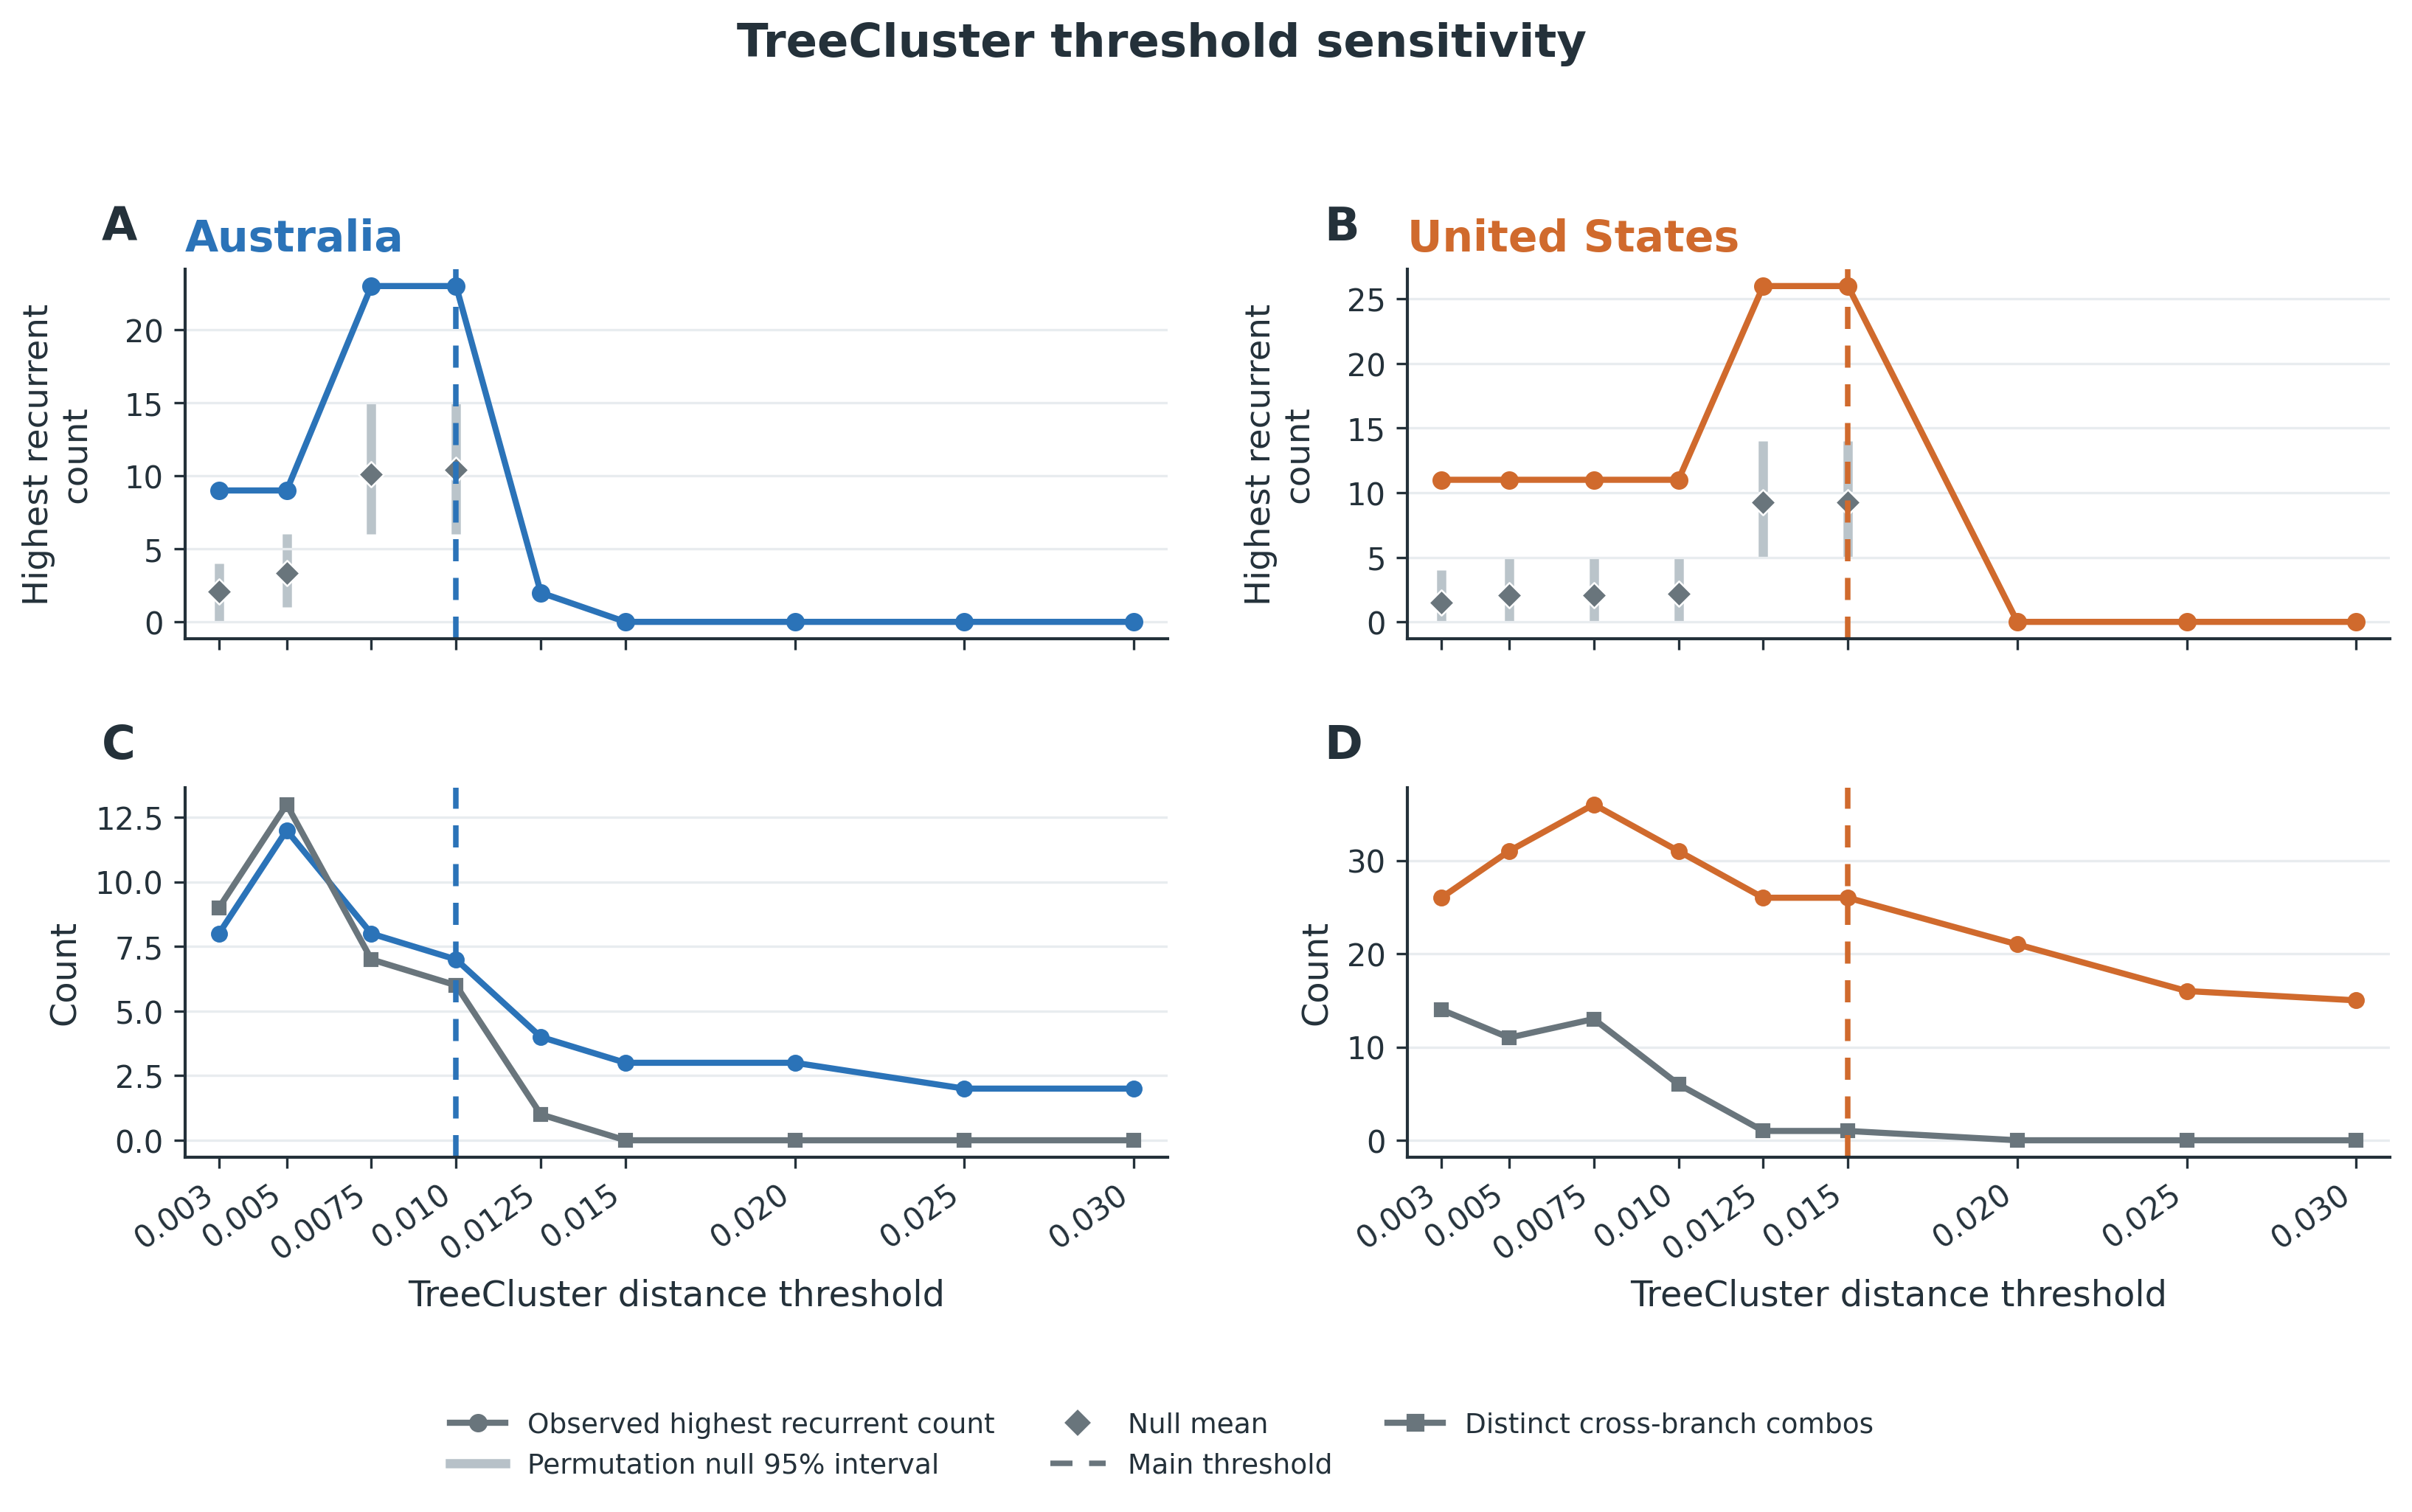

In [4]:
BLUE = '#2b73b8'
ORANGE = '#d06a2d'
DARK = '#24313a'
MID = '#69757c'
GRID = '#e8ecef'
COHORT_COLORS = {'Australia': BLUE, 'United States': ORANGE}

mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.linewidth': 1.0,
    'axes.edgecolor': DARK,
    'axes.labelcolor': DARK,
    'xtick.color': DARK,
    'ytick.color': DARK,
    'text.color': DARK,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
})

fig, axes = plt.subplots(2, 2, figsize=(11.4, 6.8), dpi=300, sharex=True)
for col, cohort in enumerate(['Australia', 'United States']):
    sub = thresholds[thresholds['project_label'].eq(cohort)].copy().sort_values('TreeCluster_threshold')
    color = COHORT_COLORS[cohort]
    main_thr = float(sub.loc[sub['is_main_threshold'], 'TreeCluster_threshold'].iloc[0])
    ax = axes[0, col]
    analyzable = sub['analysis_status'].eq('analyzable') & sub['permuted_mean'].notna()
    ax.vlines(sub.loc[analyzable, 'TreeCluster_threshold'], sub.loc[analyzable, 'permuted_q025'], sub.loc[analyzable, 'permuted_q975'], color='#b7c1c8', linewidth=3.0, alpha=0.95, zorder=1)
    ax.scatter(sub.loc[analyzable, 'TreeCluster_threshold'], sub.loc[analyzable, 'permuted_mean'], marker='D', s=34, color=MID, edgecolor='white', linewidth=0.6, zorder=2)
    ax.plot(sub['TreeCluster_threshold'], sub['dominant_combo_samples'], 'o-', color=color, linewidth=2.0, markersize=5, zorder=3)
    ax.axvline(main_thr, color=color, linestyle=(0, (4, 3)), linewidth=1.8)
    ax.set_title(cohort, loc='left', color=color, fontsize=14, fontweight='bold')
    ax.set_ylabel('Highest recurrent\ncount', fontsize=11.2, labelpad=10)
    ax.grid(axis='y', color=GRID)
    ax.spines[['top', 'right']].set_visible(False)
    ax2 = axes[1, col]
    ax2.plot(sub['TreeCluster_threshold'], sub['n_treecluster_branches'], 'o-', color=color, linewidth=2, markersize=4.5, label='TreeCluster branches')
    ax2.plot(sub['TreeCluster_threshold'], sub['n_distinct_cross_branch_combos'], 's-', color=MID, linewidth=2, markersize=4, label='Distinct cross-branch combos')
    ax2.axvline(main_thr, color=color, linestyle=(0, (4, 3)), linewidth=1.8)
    ax2.set_ylabel('Count', fontsize=11.5)
    ax2.set_xlabel('TreeCluster distance threshold', fontsize=11.5)
    ax2.grid(axis='y', color=GRID)
    ax2.spines[['top', 'right']].set_visible(False)
    ax2.set_xlim(0.002, 0.031)
    ax2.set_xticks([0.003, 0.005, 0.0075, 0.010, 0.0125, 0.015, 0.020, 0.025, 0.030])
    ax2.set_xticklabels(['0.003', '0.005', '0.0075', '0.010', '0.0125', '0.015', '0.020', '0.025', '0.030'], rotation=35, ha='right')
axes[0, 0].text(-0.085, 1.08, 'A', transform=axes[0, 0].transAxes, fontsize=15, fontweight='bold')
axes[0, 1].text(-0.085, 1.08, 'B', transform=axes[0, 1].transAxes, fontsize=15, fontweight='bold')
axes[1, 0].text(-0.085, 1.08, 'C', transform=axes[1, 0].transAxes, fontsize=15, fontweight='bold')
axes[1, 1].text(-0.085, 1.08, 'D', transform=axes[1, 1].transAxes, fontsize=15, fontweight='bold')
handles = [
    mpl.lines.Line2D([], [], color=MID, marker='o', linestyle='-', linewidth=2.0, markersize=5, label='Observed highest recurrent count'),
    mpl.lines.Line2D([], [], color='#b7c1c8', linewidth=3.0, label='Permutation null 95% interval'),
    mpl.lines.Line2D([], [], color=MID, marker='D', linestyle='None', markersize=5, label='Null mean'),
    mpl.lines.Line2D([], [], color=MID, linestyle=(0, (4, 3)), linewidth=1.8, label='Main threshold'),
    mpl.lines.Line2D([], [], color=MID, marker='s', linestyle='-', linewidth=2.0, markersize=5, label='Distinct cross-branch combos'),
]
fig.legend(handles=handles, frameon=False, fontsize=9.0, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.005))
fig.suptitle('TreeCluster threshold sensitivity', fontsize=15, fontweight='bold', y=0.99)
fig.tight_layout(rect=(0.035, 0.11, 1, 0.95), w_pad=2.5, h_pad=2.0)
paths = au.save_pub_figure(fig, FIG_DIR, 'Supplementary_Figure_S6_TreeCluster_threshold_sensitivity', dpi=600)
display(Markdown('Saved: ' + ', '.join(paths.values())))
plt.show()
